<a href="https://colab.research.google.com/github/Milonahmed96/Credit-Risk-AI/blob/main/notebooks/04_ai_decision_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Engineering & The Decision Engine
In a real-world banking environment, a Machine Learning model is never deployed bare. It must be integrated into a **Decision Engine** that combines statistical probabilities with hardcoded business policies (e.g., "Do not approve anyone who is currently 3 months late on another loan, regardless of their ML score").

Furthermore, financial regulations require strict **Audit Trails**. If a regulator or a customer asks why a loan was rejected, the bank must provide a timestamped, logged reason.

In this notebook, we build a production-grade `CreditDecisionEngine` that:
1. Enforces hard policy rules.
2. Evaluates the applicant using our XGBoost Pipeline (using our optimized 0.42 threshold).
3. Generates a compliance-ready Audit Log.

In [25]:
# import packages
import os
import pandas as pd
import numpy as np
import datetime
import joblib
import json
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family': 'sans-serif', 'axes.titlesize': 14, 'axes.titleweight': 'bold', 'figure.dpi': 120})
sns.set_style("whitegrid")

# 1. Load the Test Data (Simulating incoming live applications)
github_test = 'https://raw.githubusercontent.com/Milonahmed96/Credit-Risk-AI/main/data/test_processed.csv'
try:
    live_traffic = pd.read_csv(github_test)
except Exception:
    live_traffic = pd.read_csv('test_processed.csv')

X_live = live_traffic.drop('default', axis=1)
y_actual = live_traffic['default']

# 2. Smart Model Downloader
model_url = 'https://raw.githubusercontent.com/Milonahmed96/Credit-Risk-AI/main/models/xgboost_model_pipeline.pkl'
local_model_path = 'xgboost_model_pipeline.pkl'
urllib.request.urlretrieve(model_url)

('/tmp/tmp2yrh1bjy', <http.client.HTTPMessage at 0x7e3b7f3bb3b0>)

# Building the Credit Decision Engine
We wrap our ML pipeline inside a Python class. This engine simulates how a backend software system processes loan applications.

**The Logic Flow:**
1. **Rule 1 (Severe Delinquency):** If average payment delay > 2 months -> Auto-Reject.
2. **Rule 2 (Credit Exhaustion):** If utilization ratio > 95% -> Auto-Reject.
3. **ML Scoring:** If they pass the rules, feed data to the XGBoost Pipeline.
4. **Threshold Check:** If probability >= 0.42 -> Reject. Else -> Approve.

In [26]:
import shap

class CreditDecisionEngine:
    def __init__(self, model_pipeline, optimal_threshold=0.42):
        self.model = model_pipeline
        self.threshold = optimal_threshold
        self.audit_log = []

        # Initialize SHAP explainer directly on the XGBoost step
        self.xgb_model = self.model.named_steps['classifier']
        self.explainer = shap.TreeExplainer(self.xgb_model)

    def _get_top_risk_factor(self, application_data):
        """Calculates SHAP values for a single applicant to find their #1 risk driver."""
        #Pass data through the pipeline's preprocessor
        transformed_data = self.model.named_steps['preprocessor'].transform(application_data)

        # Get SHAP values for this specific person
        shap_vals = self.explainer.shap_values(transformed_data)

        # Dynamically reconstruct feature names
        cat_cols = ['sex', 'education', 'marriage']
        num_cols = [c for c in application_data.columns if c not in cat_cols]
        cat_encoder = self.model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
        cat_features = list(cat_encoder.get_feature_names_out(cat_cols))
        all_features = num_cols + cat_features

        # Find the feature that pushed the risk score the highest
        top_feature_idx = np.argmax(shap_vals[0])
        return all_features[top_feature_idx]

    def evaluate_application(self, customer_id, application_data):
        # Hard Business Policy Rules
        if application_data['avg_payment_delay'].values[0] >= 2.0:
            return self._log_decision(customer_id, "REJECT", "Policy: Severe Historical Delinquency", None)

        if application_data['utilization_ratio'].values[0] >= 0.95:
            return self._log_decision(customer_id, "REJECT", "Policy: Credit Utilization > 95%", None)

        # ML Evaluation
        ml_prob = self.model.predict_proba(application_data)[:, 1][0]

        # hreshold & SHAP Application
        if ml_prob >= self.threshold:
            # Generate local explainability for the rejection!
            top_risk = self._get_top_risk_factor(application_data)
            reason = f"ML Model Reject (Top Risk Factor: {top_risk})"
            return self._log_decision(customer_id, "REJECT", reason, ml_prob)
        else:
            return self._log_decision(customer_id, "APPROVE", "Passed Policy and ML Risk Check", ml_prob)

    def _log_decision(self, customer_id, decision, reason, ml_prob):
        log_entry = {
            "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "customer_id": customer_id,
            "decision": decision,
            "rejection_reason": reason if decision == "REJECT" else "N/A",
            "ml_probability": round(float(ml_prob), 4) if ml_prob is not None else "Bypassed"
        }
        self.audit_log.append(log_entry)
        return log_entry

    def get_audit_dataframe(self):
        return pd.DataFrame(self.audit_log)

# Simulating Production Traffic
We will now simulate **1,000 live loan applications** hitting our backend servers. We initialize the engine and loop the applicants through it, generating our regulatory audit trail.

In [27]:
# Initialize the engine
decision_engine = CreditDecisionEngine(model_pipeline=ml_pipeline, optimal_threshold=0.42)

print("Processing 1,000 live applications through the Decision Engine...\n")

# Simulate 1000 applications
num_applicants_to_simulate = 1000

# We create mock Customer IDs (e.g., CUST-100001)
for i in range(num_applicants_to_simulate):
    customer_id = f"CUST-{100000 + i}"

    # Extract a single row as a DataFrame to simulate a live JSON payload
    single_application = X_live.iloc[[i]]

    # Process through the engine
    decision_engine.evaluate_application(customer_id, single_application)

# Retrieve the Audit Log
audit_df = decision_engine.get_audit_dataframe()

# Display the first 10 decisions for the compliance team
print("Recent Audit Log Entries:")
display(audit_df.head(10))

Processing 1,000 live applications through the Decision Engine...

Recent Audit Log Entries:


,timestamp,customer_id,decision,rejection_reason,ml_probability
0,2026-02-24 22:32:19,CUST-100000,APPROVE,N/A,0.2781
1,2026-02-24 22:32:19,CUST-100001,REJECT,ML Model Reject (Top Risk Factor: pay_amt3),0.4426
2,2026-02-24 22:32:19,CUST-100002,REJECT,Policy: Credit Utilization > 95%,Bypassed
3,2026-02-24 22:32:19,CUST-100003,REJECT,Policy: Credit Utilization > 95%,Bypassed
4,2026-02-24 22:32:19,CUST-100004,APPROVE,N/A,0.055
5,2026-02-24 22:32:19,CUST-100005,REJECT,Policy: Credit Utilization > 95%,Bypassed
6,2026-02-24 22:32:19,CUST-100006,APPROVE,N/A,0.3293
7,2026-02-24 22:32:19,CUST-100007,APPROVE,N/A,0.0853
8,2026-02-24 22:32:19,CUST-100008,APPROVE,N/A,0.2061
9,2026-02-24 22:32:19,CUST-100009,APPROVE,N/A,0.1253


# Compliance Reporting & Saving Logs
Finally, we analyze the behavior of our decision engine. How many people were blocked by hard rules versus the ML model?

We visualize this distribution and save the audit trail to disk (simulating saving to a secure AWS S3 bucket or database) so regulators can inspect it.

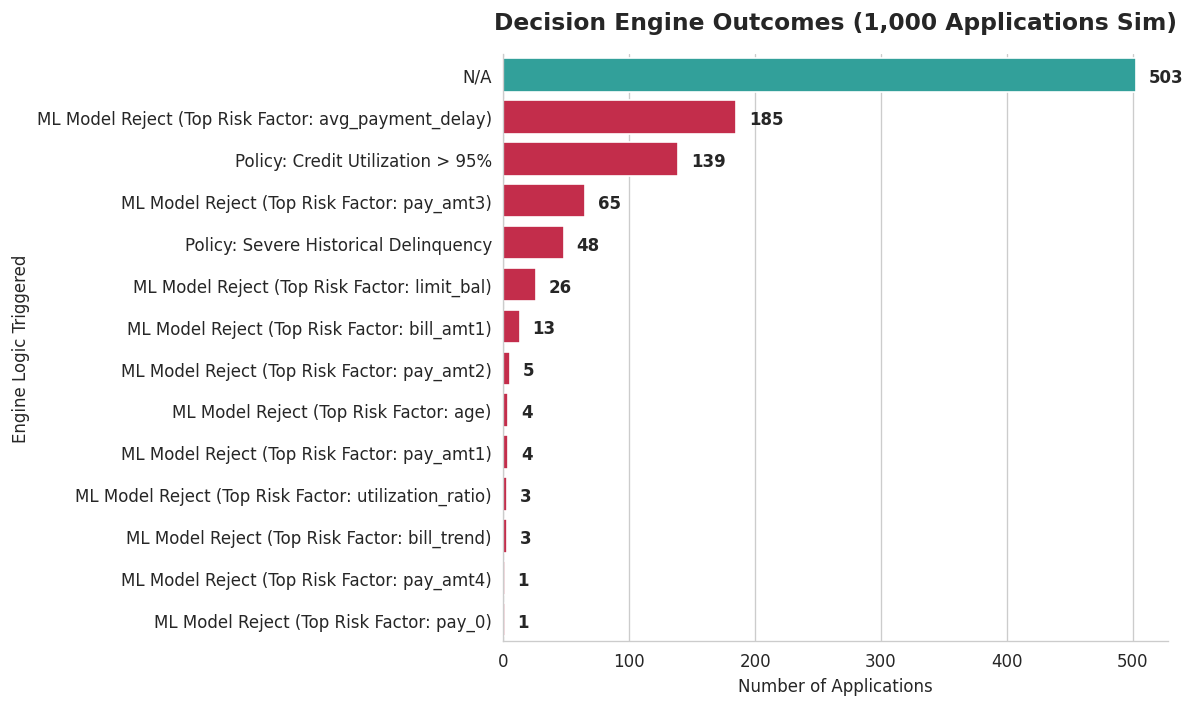

Total Approved: 503 (50.3%)
Total Rejected: 497 (49.7%)


In [28]:
# 1. Create a logs directory
if not os.path.exists('logs'):
    os.makedirs('logs')

# 2. Save the Audit Trail
audit_df.to_csv('logs/production_audit_trail.csv', index=False)

# 3. Analyze Decision Distribution
decision_counts = audit_df['rejection_reason'].value_counts().reset_index()
decision_counts.columns = ['Outcome / Reason', 'Count']

# 4. Plot the Business Report
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=decision_counts, y='Outcome / Reason', x='Count',
                 palette=['#20B2AA' if 'N/A' in x else '#DC143C' for x in decision_counts['Outcome / Reason']])

plt.title('Decision Engine Outcomes (1,000 Applications Sim)', pad=15)
plt.xlabel('Number of Applications')
plt.ylabel('Engine Logic Triggered')

# Add exact numbers to bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 10, p.get_y() + p.get_height()/2. + 0.05, f'{int(width)}', ha="left", va="center", fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# Print summary
approved = len(audit_df[audit_df['decision'] == 'APPROVE'])
rejected = len(audit_df[audit_df['decision'] == 'REJECT'])
print(f"Total Approved: {approved} ({approved/num_applicants_to_simulate*100:.1f}%)")
print(f"Total Rejected: {rejected} ({rejected/num_applicants_to_simulate*100:.1f}%)")

In [29]:
# Install FastAPI and HTTPX
!pip -q install fastapi httpx pydantic

from fastapi.testclient import TestClient
import json

# We will use the 'app'
# from src.app import app
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Dict
import datetime

# Setup the test app
test_app = FastAPI()
class LoanApplication(BaseModel):
    customer_id: str
    features: Dict[str, float]

@test_app.post("/predict")
def predict_credit_risk(application: LoanApplication):
    app_data = pd.DataFrame([application.features])

    # Hard Rules Check
    if app_data['avg_payment_delay'].values[0] >= 2.0:
        return {"decision": "REJECT", "reason": "Policy Rule: Severe Delinquency", "timestamp": datetime.datetime.now().isoformat()}
    if app_data['utilization_ratio'].values[0] >= 0.95:
        return {"decision": "REJECT", "reason": "Policy Rule: Credit Exhaustion", "timestamp": datetime.datetime.now().isoformat()}

    # ML Check
    ml_prob = ml_pipeline.predict_proba(app_data)[:, 1][0]
    if ml_prob >= 0.42:
        return {"decision": "REJECT", "reason": "ML Model: High Default Risk", "probability": round(float(ml_prob), 4)}

    return {"decision": "APPROVE", "reason": "Passed Policy and ML", "probability": round(float(ml_prob), 4)}


# THE ACTUAL TEST
client = TestClient(test_app)

# Grab Customer #5 from our live traffic to test
sample_customer = X_live.iloc[5]
customer_dict = sample_customer.to_dict()

# Format it exactly how a Web App or Mobile App would send it (JSON)
api_payload = {
    "customer_id": "WEB-CUST-999",
    "features": customer_dict
}

# Hit the API endpoint
response = client.post("/predict", json=api_payload)

# Read the API's response
print(f"📥 API Status Code: {response.status_code}")
print("🔍 API JSON Response:")
print(json.dumps(response.json(), indent=4))

📥 API Status Code: 200
🔍 API JSON Response:
{
    "decision": "REJECT",
    "reason": "Policy Rule: Credit Exhaustion",
    "timestamp": "2026-02-24T22:32:39.334082"
}
